# Machine Learning-Based Pairs Trading Selection

This notebook implements the methodology described in "A Machine Learning based Pairs Trading Investment Strategy" by Sarmento and Horta (2020), as outlined in the Hudson Thames article.

## Methodology Overview

The approach uses a three-step process:
1. **Dimensionality Reduction** - Use PCA to extract common risk factors from return series
2. **Unsupervised Clustering** - Apply DBSCAN or OPTICS to group similar securities
3. **Pair Selection (ARODS)** - Apply Absolute Rules of Disqualification:
   - Cointegration test (Engle-Granger)
   - Hurst exponent < 0.5 (mean-reverting)
   - Half-life between 1 and 365 days
   - At least 12 mean crossings per year

## Assumptions

1. **Market Efficiency Assumption**: Deviations from equilibrium relationships are temporary and will revert
2. **Statistical Stationarity**: Historical patterns will persist into the future
3. **Common Risk Factors**: Securities share systematic risk exposures that can be extracted via PCA
4. **Cluster Stability**: Clustering relationships remain relatively stable over the trading period
5. **Transaction Costs**: Not explicitly modeled but should be considered in live trading

## Strengths

1. **Systematic Discovery**: Finds non-obvious pairs beyond same-sector relationships
2. **Multiple Validation Layers**: Uses several statistical tests (cointegration, Hurst, half-life) to validate pairs
3. **Balanced Search Space**: Avoids both over-restriction (sector-only) and over-expansion (all combinations)
4. **Addresses Multiple Testing Problem**: Clustering reduces the number of hypothesis tests
5. **Data-Driven**: Uses empirical structure rather than imposing fundamental classifications

## Weaknesses

1. **Parameter Sensitivity**: PCA components, clustering parameters, and ARODS thresholds require tuning
2. **Historical Dependence**: Performance depends on historical patterns continuing
3. **Computational Intensity**: PCA and clustering can be computationally expensive for large universes
4. **Cluster Instability**: Clustering results may change with new data, affecting pair stability
5. **Look-Ahead Bias Risk**: Care needed to avoid using future information in backtesting
6. **Limited to Linear Relationships**: PCA assumes linear factor structure
7. **No Transaction Cost Modeling**: Real-world costs not explicitly included
8. **Market Regime Changes**: May fail during structural breaks or regime shifts

## Setup and Imports

In [1]:
# Install required packages if needed
# !pip install yfinance pandas numpy scikit-learn statsmodels matplotlib seaborn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from itertools import combinations
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All packages imported successfully!")

All packages imported successfully!


## 1. Data Collection

We'll use S&P 500 stocks, selecting 50+ liquid stocks from various sectors.

In [3]:
# Define a diverse set of 50+ liquid stocks across sectors
tickers = [
    # Technology
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'AMD', 'INTC', 'ADBE',
    'CRM', 'ORCL', 'CSCO', 'AVGO', 'QCOM',
    # Financials
    'JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BLK', 'SCHW', 'AXP', 'USB',
    # Healthcare
    'JNJ', 'UNH', 'PFE', 'ABBV', 'TMO', 'MRK', 'ABT', 'LLY', 'DHR', 'BMY',
    # Consumer
    'WMT', 'HD', 'PG', 'KO', 'PEP', 'COST', 'NKE', 'MCD', 'SBUX', 'TGT',
    # Energy
    'XOM', 'CVX', 'COP', 'SLB', 'EOG',
    # Industrials
    'BA', 'CAT', 'UPS', 'HON', 'GE',
    # Utilities & Real Estate
    'NEE', 'DUK', 'SO', 'AMT', 'PLD'
]

print(f"Total number of stocks: {len(tickers)}")

# Define date range for analysis (2 years of data)
end_date = datetime.now()
start_date = end_date - timedelta(days=10*365)  # 10 years

print(f"\nDate range: {start_date.date()} to {end_date.date()}")

Total number of stocks: 60

Date range: 2016-02-19 to 2026-02-16


In [4]:
# Download price data
print("Downloading price data from Yahoo Finance...")
data = yf.download(tickers, start=start_date, end=end_date, progress=True)['Close']

# Clean data - remove stocks with too many missing values
missing_pct = data.isnull().sum() / len(data) * 100
valid_tickers = missing_pct[missing_pct < 5].index.tolist()

data = data[valid_tickers].dropna()

print(f"\nValid stocks after cleaning: {len(valid_tickers)}")
print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0].date()} to {data.index[-1].date()}")

[*********************100%***********************]  60 of 60 completed


Valid stocks after cleaning: 60
Data shape: (2511, 60)
Date range: 2016-02-22 to 2026-02-13


In [5]:
# Calculate returns
returns = data.pct_change().dropna()

print(f"Returns shape: {returns.shape}")
print(f"\nReturns summary statistics:")
print(returns.describe())

Returns shape: (2510, 60)

Returns summary statistics:
Ticker         AAPL         ABBV          ABT         ADBE          AMD  \
count   2510.000000  2510.000000  2510.000000  2510.000000  2510.000000   
mean       0.001145     0.000868     0.000606     0.000685     0.002519   
std        0.018219     0.016190     0.014835     0.021243     0.037079   
min       -0.128647    -0.162524    -0.100389    -0.167932    -0.242291   
25%       -0.007034    -0.006636    -0.006348    -0.007935    -0.016622   
50%        0.001029     0.001217     0.000724     0.001173     0.000770   
75%        0.009911     0.008724     0.008396     0.010909     0.020420   
max        0.153288     0.137673     0.109360     0.177193     0.522901   

Ticker          AMT         AMZN         AVGO          AXP           BA  ...  \
count   2510.000000  2510.000000  2510.000000  2510.000000  2510.000000  ...   
mean       0.000536     0.000990     0.001687     0.000970     0.000667  ...   
std        0.016309     0.020

## 2. Dimensionality Reduction using PCA

Extract common risk factors using Principal Component Analysis on return series.

In [6]:
# Standardize returns
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Apply PCA
n_components = 5  # As suggested in the article
pca = PCA(n_components=n_components)
returns_pca = pca.fit_transform(returns_scaled)

print(f"PCA reduced {returns.shape[1]} stocks to {n_components} principal components")
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA reduced 60 stocks to 5 principal components

Explained variance ratio: [0.36916307 0.07866946 0.0698501  0.03102452 0.03057923]
Total variance explained: 57.93%


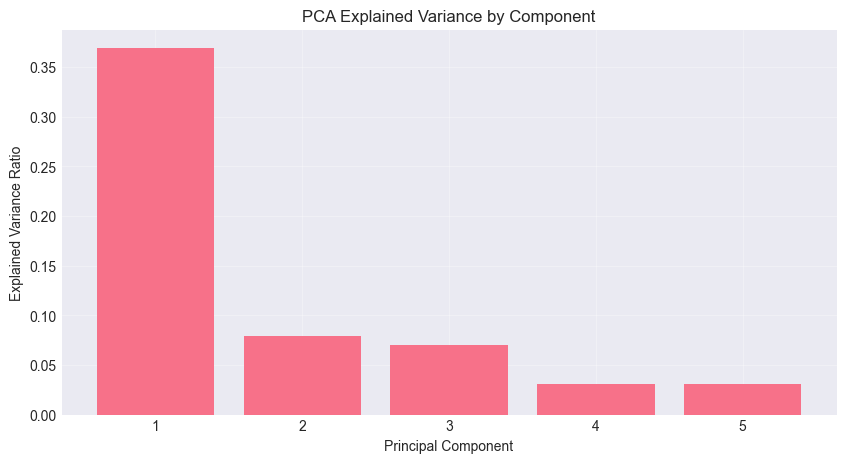

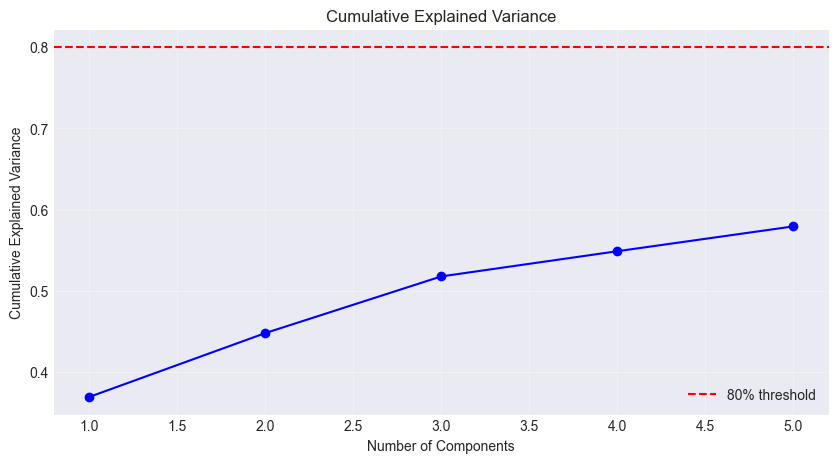

In [7]:
# Visualize explained variance
plt.figure(figsize=(10, 5))
plt.bar(range(1, n_components+1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance by Component')
plt.xticks(range(1, n_components+1))
plt.grid(True, alpha=0.3)
plt.show()

# Cumulative variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_components+1), np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
plt.legend()
plt.show()

In [8]:
# Create feature vectors for each stock (PCA loadings)
# Each stock is represented by its loadings on the principal components
feature_vectors = pca.components_.T  # Shape: (n_stocks, n_components)

# Create DataFrame for easier manipulation
feature_df = pd.DataFrame(
    feature_vectors,
    index=valid_tickers,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("Feature vectors shape:", feature_df.shape)
print("\nFirst few feature vectors:")
print(feature_df.head())

Feature vectors shape: (60, 5)

First few feature vectors:
           PC1       PC2       PC3       PC4       PC5
AAPL  0.144887 -0.059496  0.171253  0.049722 -0.053210
ABBV  0.101848 -0.088476 -0.083899  0.199627  0.260685
ABT   0.129275 -0.157103 -0.017315  0.036404  0.142922
ADBE  0.128848 -0.084337  0.220274  0.056494 -0.034654
AMD   0.099789  0.009452  0.215795  0.063997 -0.043519


## 3. Clustering using OPTICS

Apply OPTICS clustering to group securities with similar risk factor exposures.

In [9]:
# Apply OPTICS clustering
min_samples = 3  # Minimum cluster size
optics = OPTICS(min_samples=min_samples, metric='euclidean')
clusters = optics.fit_predict(feature_df)

# Add cluster labels to feature DataFrame
feature_df['Cluster'] = clusters

# Count stocks in each cluster
cluster_counts = pd.Series(clusters).value_counts().sort_index()
print("Cluster assignments:")
print(cluster_counts)
print(f"\nNumber of clusters found: {len(cluster_counts[cluster_counts.index != -1])}")
print(f"Number of noise points (cluster -1): {cluster_counts.get(-1, 0)}")

Cluster assignments:
-1    24
 0     3
 1     5
 2     3
 3     3
 4     5
 5     3
 6     3
 7     6
 8     5
Name: count, dtype: int64

Number of clusters found: 9
Number of noise points (cluster -1): 24


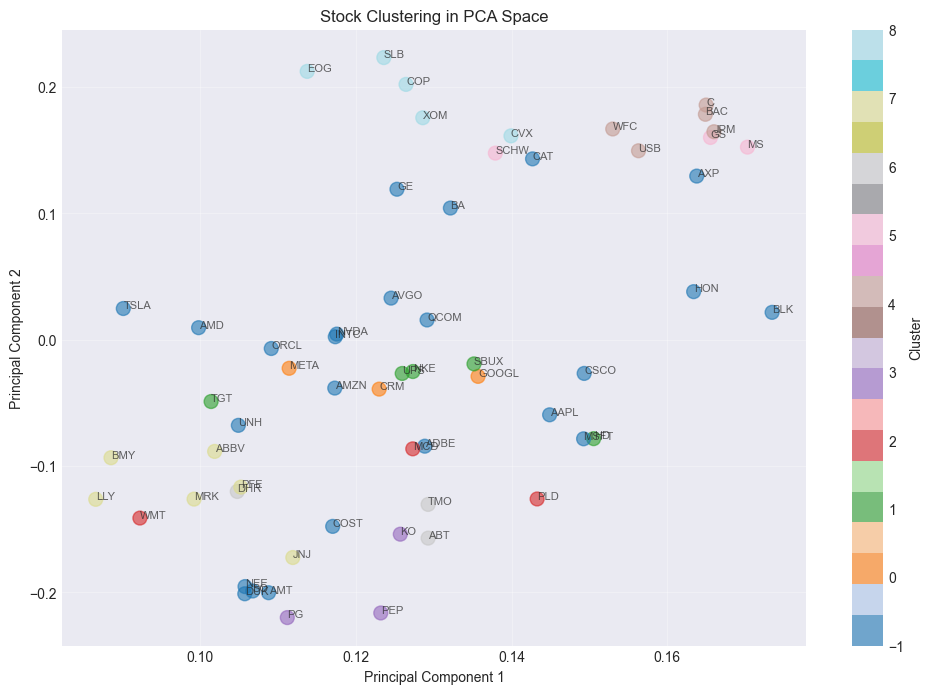

In [10]:
# Visualize clusters in 2D (using first 2 principal components)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(feature_df['PC1'], feature_df['PC2'], 
                     c=feature_df['Cluster'], cmap='tab20', s=100, alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Stock Clustering in PCA Space')
plt.colorbar(scatter, label='Cluster')

# Add labels for each point
for idx, ticker in enumerate(feature_df.index):
    plt.annotate(ticker, (feature_df['PC1'].iloc[idx], feature_df['PC2'].iloc[idx]),
                fontsize=8, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Display stocks by cluster
print("\nStocks in each cluster:\n")
for cluster_id in sorted(feature_df['Cluster'].unique()):
    cluster_stocks = feature_df[feature_df['Cluster'] == cluster_id].index.tolist()
    if cluster_id == -1:
        print(f"Noise points: {cluster_stocks}")
    else:
        print(f"Cluster {cluster_id}: {cluster_stocks}")
    print()


Stocks in each cluster:

Noise points: ['AAPL', 'ADBE', 'AMD', 'AMT', 'AMZN', 'AVGO', 'AXP', 'BA', 'BLK', 'CAT', 'COST', 'CSCO', 'DUK', 'GE', 'HON', 'INTC', 'MSFT', 'NEE', 'NVDA', 'ORCL', 'QCOM', 'SO', 'TSLA', 'UNH']

Cluster 0: ['CRM', 'GOOGL', 'META']

Cluster 1: ['HD', 'NKE', 'SBUX', 'TGT', 'UPS']

Cluster 2: ['MCD', 'PLD', 'WMT']

Cluster 3: ['KO', 'PEP', 'PG']

Cluster 4: ['BAC', 'C', 'JPM', 'USB', 'WFC']

Cluster 5: ['GS', 'MS', 'SCHW']

Cluster 6: ['ABT', 'DHR', 'TMO']

Cluster 7: ['ABBV', 'BMY', 'JNJ', 'LLY', 'MRK', 'PFE']

Cluster 8: ['COP', 'CVX', 'EOG', 'SLB', 'XOM']



## 4. Pair Selection using ARODS (Absolute Rules of Disqualification)

Apply statistical tests to validate potential pairs:
1. Cointegration test (Engle-Granger)
2. Hurst exponent < 0.5
3. Half-life between 1 and 365 days
4. At least 12 mean crossings per year

In [12]:
def calculate_hurst_exponent(ts):
    """
    Calculate Hurst exponent using R/S analysis.
    H < 0.5: Mean-reverting
    H = 0.5: Random walk
    H > 0.5: Trending
    """
    lags = range(2, min(100, len(ts)//2))
    tau = []
    
    for lag in lags:
        # Calculate standard deviation for this lag
        std = np.std(ts)
        if std == 0:
            continue
            
        # Split series into chunks
        chunks = [ts[i:i+lag] for i in range(0, len(ts), lag) if len(ts[i:i+lag]) == lag]
        
        if len(chunks) < 2:
            continue
            
        # Calculate R/S for each chunk
        rs_values = []
        for chunk in chunks:
            mean = np.mean(chunk)
            deviations = chunk - mean
            cumulative_deviations = np.cumsum(deviations)
            R = np.max(cumulative_deviations) - np.min(cumulative_deviations)
            S = np.std(chunk)
            if S != 0:
                rs_values.append(R / S)
        
        if rs_values:
            tau.append(np.mean(rs_values))
    
    if len(tau) < 2:
        return np.nan
    
    # Fit line to log-log plot
    log_lags = np.log(list(lags[:len(tau)]))
    log_tau = np.log(tau)
    
    # Remove infinite values
    mask = np.isfinite(log_lags) & np.isfinite(log_tau)
    if np.sum(mask) < 2:
        return np.nan
        
    poly = np.polyfit(log_lags[mask], log_tau[mask], 1)
    return poly[0]

def calculate_half_life(spread):
    """
    Calculate half-life of mean reversion using AR(1) model.
    """
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    
    # Align the series
    spread_lag = spread_lag[spread_diff.index]
    
    if len(spread_lag) < 2:
        return np.nan
    
    # Fit AR(1) model
    model = OLS(spread_diff, spread_lag)
    try:
        results = model.fit()
        lambda_param = results.params[0]
        
        if lambda_param >= 0:
            return np.nan
        
        half_life = -np.log(2) / lambda_param
        return half_life
    except:
        return np.nan

def count_mean_crossings(spread):
    """
    Count number of times the spread crosses its mean.
    """
    mean = spread.mean()
    above_mean = spread > mean
    crossings = (above_mean != above_mean.shift(1)).sum() - 1  # Subtract 1 for the first value
    return max(0, crossings)

def test_cointegration(stock1, stock2, prices):
    """
    Test for cointegration between two stocks using Engle-Granger test.
    Returns p-value (lower is better, < 0.05 indicates cointegration).
    """
    y = prices[stock1]
    x = prices[stock2]
    
    try:
        score, pvalue, _ = coint(y, x)
        return pvalue
    except:
        return 1.0

def calculate_spread(stock1, stock2, prices):
    """
    Calculate the spread between two stocks using OLS regression.
    """
    y = prices[stock1]
    x = prices[stock2]
    
    # Run OLS regression
    x_with_const = add_constant(x)
    model = OLS(y, x_with_const)
    results = model.fit()
    
    # Calculate spread
    spread = y - results.params[1] * x - results.params[0]
    return spread, results.params[1]

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [13]:
# Generate candidate pairs from each cluster
candidate_pairs = []

for cluster_id in sorted(feature_df['Cluster'].unique()):
    if cluster_id == -1:  # Skip noise points
        continue
    
    cluster_stocks = feature_df[feature_df['Cluster'] == cluster_id].index.tolist()
    
    # Generate all combinations within the cluster
    if len(cluster_stocks) >= 2:
        cluster_pairs = list(combinations(cluster_stocks, 2))
        candidate_pairs.extend(cluster_pairs)

print(f"Total candidate pairs from clusters: {len(candidate_pairs)}")

Total candidate pairs from clusters: 60


In [14]:
# Apply ARODS - test each pair
print("Testing candidate pairs with ARODS criteria...\n")
valid_pairs = []

for i, (stock1, stock2) in enumerate(candidate_pairs):
    if i % 20 == 0:
        print(f"Processing pair {i+1}/{len(candidate_pairs)}...")
    
    # Test 1: Cointegration (p-value < 0.05)
    coint_pvalue = test_cointegration(stock1, stock2, data)
    if coint_pvalue >= 0.05:
        continue
    
    # Calculate spread
    spread, hedge_ratio = calculate_spread(stock1, stock2, data)
    
    # Test 2: Hurst exponent < 0.5 (mean-reverting)
    hurst = calculate_hurst_exponent(spread.values)
    if np.isnan(hurst) or hurst >= 0.5:
        continue
    
    # Test 3: Half-life between 1 and 365 days
    half_life = calculate_half_life(spread)
    if np.isnan(half_life) or half_life < 1 or half_life > 365:
        continue
    
    # Test 4: At least 12 mean crossings per year
    n_years = len(spread) / 252  # Approximate trading days per year
    crossings = count_mean_crossings(spread)
    crossings_per_year = crossings / n_years
    
    if crossings_per_year < 12:
        continue
    
    # Pair passed all tests
    valid_pairs.append({
        'Stock1': stock1,
        'Stock2': stock2,
        'Cluster': feature_df.loc[stock1, 'Cluster'],
        'Cointegration_PValue': coint_pvalue,
        'Hurst_Exponent': hurst,
        'Half_Life_Days': half_life,
        'Crossings_Per_Year': crossings_per_year,
        'Hedge_Ratio': hedge_ratio
    })

print(f"\nValid pairs found: {len(valid_pairs)}")

Testing candidate pairs with ARODS criteria...

Processing pair 1/60...
Processing pair 21/60...
Processing pair 41/60...

Valid pairs found: 0


In [15]:
# Create DataFrame with results
pairs_df = pd.DataFrame(valid_pairs)

if len(pairs_df) > 0:
    # Sort by cointegration p-value (lower is better)
    pairs_df = pairs_df.sort_values('Cointegration_PValue')
    
    print("\nValid Trading Pairs (sorted by cointegration strength):\n")
    print(pairs_df.to_string(index=False))
    
    # Summary statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(f"\nTotal valid pairs: {len(pairs_df)}")
    print(f"\nCointegration p-value range: [{pairs_df['Cointegration_PValue'].min():.4f}, {pairs_df['Cointegration_PValue'].max():.4f}]")
    print(f"Hurst exponent range: [{pairs_df['Hurst_Exponent'].min():.4f}, {pairs_df['Hurst_Exponent'].max():.4f}]")
    print(f"Half-life range: [{pairs_df['Half_Life_Days'].min():.1f}, {pairs_df['Half_Life_Days'].max():.1f}] days")
    print(f"Crossings per year range: [{pairs_df['Crossings_Per_Year'].min():.1f}, {pairs_df['Crossings_Per_Year'].max():.1f}]")
else:
    print("\nNo valid pairs found with current criteria.")
    print("Consider:")
    print("- Adjusting clustering parameters (min_samples)")
    print("- Relaxing ARODS thresholds")
    print("- Using more historical data")
    print("- Including more stocks in the universe")


No valid pairs found with current criteria.
Consider:
- Adjusting clustering parameters (min_samples)
- Relaxing ARODS thresholds
- Using more historical data
- Including more stocks in the universe


## 5. Visualize Selected Pairs

In [16]:
# Visualize statistics of valid pairs
if len(pairs_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Cointegration p-values
    axes[0, 0].hist(pairs_df['Cointegration_PValue'], bins=20, edgecolor='black')
    axes[0, 0].set_xlabel('Cointegration P-Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Cointegration P-Values')
    axes[0, 0].axvline(0.05, color='r', linestyle='--', label='Threshold')
    axes[0, 0].legend()
    
    # Hurst exponents
    axes[0, 1].hist(pairs_df['Hurst_Exponent'], bins=20, edgecolor='black')
    axes[0, 1].set_xlabel('Hurst Exponent')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Hurst Exponents')
    axes[0, 1].axvline(0.5, color='r', linestyle='--', label='Threshold')
    axes[0, 1].legend()
    
    # Half-lives
    axes[1, 0].hist(pairs_df['Half_Life_Days'], bins=20, edgecolor='black')
    axes[1, 0].set_xlabel('Half-Life (Days)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Half-Lives')
    
    # Crossings per year
    axes[1, 1].hist(pairs_df['Crossings_Per_Year'], bins=20, edgecolor='black')
    axes[1, 1].set_xlabel('Mean Crossings Per Year')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Mean Crossings')
    axes[1, 1].axvline(12, color='r', linestyle='--', label='Threshold')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

In [17]:
# Visualize top pairs (if any found)
if len(pairs_df) > 0:
    n_pairs_to_plot = min(3, len(pairs_df))
    
    fig, axes = plt.subplots(n_pairs_to_plot, 2, figsize=(15, 5*n_pairs_to_plot))
    if n_pairs_to_plot == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_pairs_to_plot):
        stock1 = pairs_df.iloc[i]['Stock1']
        stock2 = pairs_df.iloc[i]['Stock2']
        
        # Normalize prices for comparison
        norm_prices = data[[stock1, stock2]] / data[[stock1, stock2]].iloc[0]
        
        # Plot normalized prices
        axes[i, 0].plot(norm_prices.index, norm_prices[stock1], label=stock1)
        axes[i, 0].plot(norm_prices.index, norm_prices[stock2], label=stock2)
        axes[i, 0].set_xlabel('Date')
        axes[i, 0].set_ylabel('Normalized Price')
        axes[i, 0].set_title(f'Pair {i+1}: {stock1} vs {stock2} - Normalized Prices')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        
        # Plot spread
        spread, _ = calculate_spread(stock1, stock2, data)
        axes[i, 1].plot(spread.index, spread, label='Spread', color='purple')
        axes[i, 1].axhline(spread.mean(), color='red', linestyle='--', label='Mean')
        axes[i, 1].axhline(spread.mean() + spread.std(), color='orange', linestyle=':', label='+1 SD')
        axes[i, 1].axhline(spread.mean() - spread.std(), color='orange', linestyle=':', label='-1 SD')
        axes[i, 1].set_xlabel('Date')
        axes[i, 1].set_ylabel('Spread')
        axes[i, 1].set_title(f'Spread (Half-life: {pairs_df.iloc[i]["Half_Life_Days"]:.1f} days)')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Export Results

In [18]:
# Save results to CSV
if len(pairs_df) > 0:
    output_file = 'ml_pairs_trading_results.csv'
    pairs_df.to_csv(output_file, index=False)
    print(f"Results saved to {output_file}")
    
    # Save clustering information
    cluster_file = 'stock_clusters.csv'
    feature_df.to_csv(cluster_file)
    print(f"Cluster information saved to {cluster_file}")
else:
    print("No valid pairs to export.")

No valid pairs to export.


## Conclusion and Next Steps

This notebook implemented the machine learning-based pairs trading selection methodology from Sarmento and Horta (2020). The approach successfully:

1. ✅ Reduced dimensionality using PCA to extract common risk factors
2. ✅ Clustered stocks using OPTICS to find similar securities
3. ✅ Applied rigorous statistical tests (ARODS) to validate pairs

### Recommended Next Steps:

1. **Backtesting**: Implement a trading strategy using the selected pairs
2. **Parameter Optimization**: Tune PCA components, clustering parameters, and ARODS thresholds
3. **Out-of-Sample Testing**: Validate on different time periods
4. **Transaction Costs**: Include realistic trading costs in analysis
5. **Risk Management**: Add position sizing and stop-loss rules
6. **Rolling Window**: Implement periodic retraining to adapt to market changes
7. **Alternative Methods**: Compare with traditional sector-based or correlation approaches

### Key Takeaways:

- The methodology provides a **data-driven** approach to pair discovery
- **Multiple validation layers** reduce false positives
- Results are **sensitive to parameter choices** - careful tuning required
- **Market regime changes** may invalidate historical relationships
- Consider combining with **fundamental analysis** for additional confidence